# Experiment 3

This experiment is about the 3rd 'expected findings' from the ReadMe.md

* Remote positions will more frequently require specialized and self-directed skills compared to non-remote roles, which will emphasize broader skill sets. 

In [ ]:
!pip install scipy
!pip install seaborn


[notice] A new release of pip is available: 24.0 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


In [1]:
from pathlib import Path
import re
import matplotlib.pyplot as plt
import pandas as pd
from scipy import stats
import seaborn as sns

from helpers import parse_salary
from job_dataset_union import build_unified_jobs_df

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (14, 6)

ModuleNotFoundError: No module named 'seaborn'

In [ ]:
data_paths = [
    # Dataset 1 
    Path("data/glassdoor_jobs_2023.csv"),
    # Dataset 2
    Path("data/data_science_job_posts_2025.csv"),
]

df = build_unified_jobs_df()

required_column = "job_description_skills"
if required_column not in df.columns:
    raise ValueError(f"Expected '{required_column}' column in the unified dataset.")

job_descriptions = df[required_column].fillna("").astype(str)
print(f"Loaded {len(df)} job postings from {', '.join(str(path) for path in data_paths)}.")
print(df['source_dataset'].value_counts())


Loaded 2444 job postings from data\glassdoor_jobs_2023.csv, data\data_science_job_posts_2025.csv.
source_dataset
glassdoor_2023                 1500
data_science_job_posts_2025     944
Name: count, dtype: int64


In [ ]:
df.columns

Index(['job_title', 'location', 'sector', 'salary_range', 'industry',
       'job_description_skills', 'source_dataset', 'Rating', 'Company Name',
       'Size', 'Founded', 'Type of ownership', 'Revenue', 'seniority_level',
       'status', 'company', 'post_date', 'headquarter', 'ownership',
       'company_size', 'revenue'],
      dtype='str')

In [ ]:
df.head()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
0,Data Scientist,Remote,Education,-1,Primary & Secondary Schools,Job Overview\nA Data Scientist at ExploreLearn...,glassdoor_2023,4.2,Cambium Learning Group\n4.3,1001 to 5000 Employees,...,Company - Private,$500 million to $1 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2024 University Graduate - Data Scientist,"San Jose, CA",Information Technology,Employer Provided Salary:$83K - $153K,Computer Hardware Development,Our Company\n\nChanging the world through digi...,glassdoor_2023,4.4,Adobe\n4.4,10000+ Employees,...,Company - Public,$5 to $10 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Scientist – Entry Level 2024,"Atlanta, GA",Information Technology,Employer Provided Salary:$71K - $133K,Information Technology Support Services,Introduction\nRanked by Forbes as one of the w...,glassdoor_2023,3.9,IBM\n3.9,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist 2,"Redmond, WA",Information Technology,Employer Provided Salary:$94K - $183K,Computer Hardware Development,The Microsoft 365 team is looking for a Data S...,glassdoor_2023,4.3,Microsoft\n4.3,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Entry Level Data Scientist 2023/2024,"The Woodlands, TX",Manufacturing,$48K - $78K (Glassdoor est.),Chemical Manufacturing,"You may not realize it, but you’ve likely used...",glassdoor_2023,3.9,CPChem\n3.9,1001 to 5000 Employees,...,Company - Private,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df[df['source_dataset'] == 'glassdoor_2023']['location']\
    .value_counts()\
    .sort_values(ascending=False).head(10)

# 'Remote' is the most common location in Dataset 1, with 249 remote positions.

location
Remote               249
-1                   125
New York, NY          43
Herndon, VA           43
Boston, MA            37
San Francisco, CA     34
Mountain View, CA     32
Santa Clara, CA       27
United States         25
Houston, TX           24
Name: count, dtype: int64

In [ ]:
df[df['source_dataset'] == 'data_science_job_posts_2025']['status'].value_counts()
# 118 remote positions in Dataset 2 

status
on-site    363
hybrid     207
remote     118
Name: count, dtype: int64

In [ ]:
# All Remote Positions
df_remote = df[((df['source_dataset'] == 'glassdoor_2023') & (df['location'] == 'Remote'))
   |
   ((df['source_dataset'] == 'data_science_job_posts_2025') & (df['status'] == 'remote'))
   ]

# All the rest of the positions -- we're assume the're non remote 
df_non_remote = df[~df.index.isin(df_remote.index)]

print(len(df))
print(len(df_remote), len(df_non_remote))

2444
367 2077


In [ ]:
df_remote.head()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
0,Data Scientist,Remote,Education,-1,Primary & Secondary Schools,Job Overview\nA Data Scientist at ExploreLearn...,glassdoor_2023,4.2,Cambium Learning Group\n4.3,1001 to 5000 Employees,...,Company - Private,$500 million to $1 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,Data Scientist (C),Remote,-1,Employer Provided Salary:$65.00 - $75.00 Per Hour,-1,The Team:\nAt Client’s Artificial Intelligence...,glassdoor_2023,-1.0,IVID TEK INC,1 to 50 Employees,...,Company - Public,Unknown / Non-Applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,Data Scientist,Remote,Healthcare,Employer Provided Salary:$85K,Health Care Services & Hospitals,Details\nDepartment: Workforce Planning and An...,glassdoor_2023,3.4,Ascension\n3.4,10000+ Employees,...,Nonprofit Organization,Unknown / Non-Applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
18,Data Scientist,Remote,-1,Employer Provided Salary:$130K - $150K,-1,Roles & Responsibilities: Provides support of ...,glassdoor_2023,-1.0,Ai Vantage,Unknown,...,Company - Public,Unknown / Non-Applicable,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
22,Data Scientist II,Remote,Information Technology,Employer Provided Salary:$102K - $152K,Enterprise Software & Network Solutions,Job Description\nZendesk is looking for a Data...,glassdoor_2023,3.6,Zendesk\n3.6,1001 to 5000 Employees,...,Company - Private,$1 to $5 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_non_remote.head()

,job_title,location,sector,salary_range,industry,job_description_skills,source_dataset,Rating,Company Name,Size,...,Type of ownership,Revenue,seniority_level,status,company,post_date,headquarter,ownership,company_size,revenue
1,2024 University Graduate - Data Scientist,"San Jose, CA",Information Technology,Employer Provided Salary:$83K - $153K,Computer Hardware Development,Our Company\n\nChanging the world through digi...,glassdoor_2023,4.4,Adobe\n4.4,10000+ Employees,...,Company - Public,$5 to $10 billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Data Scientist – Entry Level 2024,"Atlanta, GA",Information Technology,Employer Provided Salary:$71K - $133K,Information Technology Support Services,Introduction\nRanked by Forbes as one of the w...,glassdoor_2023,3.9,IBM\n3.9,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Data Scientist 2,"Redmond, WA",Information Technology,Employer Provided Salary:$94K - $183K,Computer Hardware Development,The Microsoft 365 team is looking for a Data S...,glassdoor_2023,4.3,Microsoft\n4.3,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Entry Level Data Scientist 2023/2024,"The Woodlands, TX",Manufacturing,$48K - $78K (Glassdoor est.),Chemical Manufacturing,"You may not realize it, but you’ve likely used...",glassdoor_2023,3.9,CPChem\n3.9,1001 to 5000 Employees,...,Company - Private,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,Senior Data Scientist,"Dallas, TX",Telecommunications,Employer Provided Salary:$141K - $254K,Telecommunications Services,POSITION: Senior Data Scientist\n\nJOB Locatio...,glassdoor_2023,3.6,AT&T\n3.6,10000+ Employees,...,Company - Public,$10+ billion (USD),NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
def extract_unique_skills(skills_str):
    """Extract and count unique skills from job description skills string.
    
    Handles comma-separated or space-separated skill lists.
    Returns count of unique skills normalized (lowercase, stripped).
    """
    if pd.isna(skills_str):
        return 0
    
    skills_str = str(skills_str).strip()
    if not skills_str:
        return 0
    
    # Split by common delimiters: comma, semicolon, 'and', plus
    skills = re.split(r'[,;]\s*|\s+and\s+|\s*\+\s*', skills_str.lower())
    
    # Clean up whitespace and filter empty strings
    skills = [skill.strip() for skill in skills if skill.strip()]
    
    # Remove duplicates and return count
    return len(set(skills))

# Phase 1: Data Preparation

In [ ]:
df_non_remote.iloc[1790]

job_title                                                    data scientist
location                                               Singapore, Singapore
sector                                                                 <NA>
salary_range                                                        €85,616
industry                                                         Technology
job_description_skills    ['git', 'python', 'java', 'sql', 'machine lear...
source_dataset                                  data_science_job_posts_2025
Rating                                                                  NaN
Company Name                                                            NaN
Size                                                                    NaN
Founded                                                                 NaN
Type of ownership                                                       NaN
Revenue                                                                 NaN
seniority_le

In [ ]:
# df_non_remote[df_non_remote['salary_numeric'] < 20500]
# 6000.0

In [ ]:
# df_non_remote[df_non_remote[['salary_numeric']].notnull().all(axis=1)]['salary_numeric'].sort_values(ascending=False).tail(10)

In [ ]:
# Parse salaries for both remote and non-remote groups
df_remote['salary_numeric'] = df_remote['salary_range'].apply(parse_salary)
df_non_remote['salary_numeric'] = df_non_remote['salary_range'].apply(parse_salary)

# Calculate unique skill counts
df_remote['unique_skill_count'] = df_remote['job_description_skills'].apply(extract_unique_skills)
df_non_remote['unique_skill_count'] = df_non_remote['job_description_skills'].apply(extract_unique_skills)

print("Remote jobs - Salary parsing:")
print(f"  Total records: {len(df_remote)}")
print(f"  Successfully parsed: {df_remote['salary_numeric'].notna().sum()}")
print(f"  Salary range: ${df_remote['salary_numeric'].min():,.0f} - ${df_remote['salary_numeric'].max():,.0f}")
print(f"  Mean salary: ${df_remote['salary_numeric'].mean():,.0f}")
print()
print("Non-remote jobs - Salary parsing:")
print(f"  Total records: {len(df_non_remote)}")
print(f"  Successfully parsed: {df_non_remote['salary_numeric'].notna().sum()}")
print(f"  Salary range: ${df_non_remote['salary_numeric'].min():,.0f} - ${df_non_remote['salary_numeric'].max():,.0f}")
print(f"  Mean salary: ${df_non_remote['salary_numeric'].mean():,.0f}")
print()
print("Skill counts summary:")
print(f"Remote - unique skill count: mean={df_remote['unique_skill_count'].mean():.2f}, median={df_remote['unique_skill_count'].median():.1f}")
print(f"Non-remote - unique skill count: mean={df_non_remote['unique_skill_count'].mean():.2f}, median={df_non_remote['unique_skill_count'].median():.1f}")

Remote jobs - Salary parsing:
  Total records: 367
  Successfully parsed: 210
  Salary range: $26,550 - $334,222
  Mean salary: $135,458

Non-remote jobs - Salary parsing:
  Total records: 2077
  Successfully parsed: 1859
  Salary range: $20,356 - $2,986,577
  Mean salary: $135,923

Skill counts summary:
Remote - unique skill count: mean=14.68, median=13.0
Non-remote - unique skill count: mean=14.42, median=9.0


In [ ]:
# Prepare data for salary analysis (remove NaNs)
salary_remote = df_remote['salary_numeric'].dropna()
salary_non_remote = df_non_remote['salary_numeric'].dropna()

# Descriptive statistics
print("=" * 70)
print("SALARY LEVEL COMPARISON: Remote vs. Non-Remote")
print("=" * 70)
print("\nRemote Positions:")
print(f"  Count: {len(salary_remote)}")
print(f"  Mean: ${salary_remote.mean():,.2f}")
print(f"  Median: ${salary_remote.median():,.2f}")
print(f"  Std Dev: ${salary_remote.std():,.2f}")
print(f"  Q1: ${salary_remote.quantile(0.25):,.2f}")
print(f"  Q3: ${salary_remote.quantile(0.75):,.2f}")

print("\nNon-Remote Positions:")
print(f"  Count: {len(salary_non_remote)}")
print(f"  Mean: ${salary_non_remote.mean():,.2f}")
print(f"  Median: ${salary_non_remote.median():,.2f}")
print(f"  Std Dev: ${salary_non_remote.std():,.2f}")
print(f"  Q1: ${salary_non_remote.quantile(0.25):,.2f}")
print(f"  Q3: ${salary_non_remote.quantile(0.75):,.2f}")

print("\nDifference:")
print(f"  Mean difference: ${salary_remote.mean() - salary_non_remote.mean():,.2f}")
print(f"  Median difference: ${salary_remote.median() - salary_non_remote.median():,.2f}")

# Mann-Whitney U Test (non-parametric test for independent groups)
statistic, p_value = stats.mannwhitneyu(salary_remote, salary_non_remote, alternative='two-sided')

print("\n" + "=" * 70)
print("MANN-WHITNEY U TEST (Non-parametric)")
print("=" * 70)
print(f"H0: The salary distributions of remote and non-remote jobs are equal")
print(f"H1: The salary distributions differ")
print(f"\nU-statistic: {statistic:.2f}")
print(f"P-value: {p_value:.6f}")
print(f"Significance level (α): 0.05")

if p_value < 0.05:
    print(f"\n✓ RESULT: Statistically SIGNIFICANT difference (p = {p_value:.6f} < 0.05)")
    print("  We reject the null hypothesis. Remote and non-remote salaries differ significantly.")
else:
    print(f"\n✗ RESULT: NO statistically significant difference (p = {p_value:.6f} >= 0.05)")
    print("  We fail to reject the null hypothesis.")

# Calculate effect size (rank biserial correlation)
n1, n2 = len(salary_remote), len(salary_non_remote)
r = 1 - (2 * statistic) / (n1 * n2)
print(f"\nEffect size (rank biserial correlation): {r:.4f}")

SALARY LEVEL COMPARISON: Remote vs. Non-Remote

Remote Positions:
  Count: 210
  Mean: $135,457.97
  Median: $127,750.00
  Std Dev: $56,015.48
  Q1: $100,000.00
  Q3: $172,061.62

Non-Remote Positions:
  Count: 1859
  Mean: $135,922.82
  Median: $125,440.47
  Std Dev: $101,106.28
  Q1: $102,500.00
  Q3: $164,270.63

Difference:
  Mean difference: $-464.85
  Median difference: $2,309.53

MANN-WHITNEY U TEST (Non-parametric)
H0: The salary distributions of remote and non-remote jobs are equal
H1: The salary distributions differ

U-statistic: 200732.50
P-value: 0.499838
Significance level (α): 0.05

✗ RESULT: NO statistically significant difference (p = 0.499838 >= 0.05)
  We fail to reject the null hypothesis.

Effect size (rank biserial correlation): -0.0284


# Phase 2: Salary Level Comparison with Statistical Significance

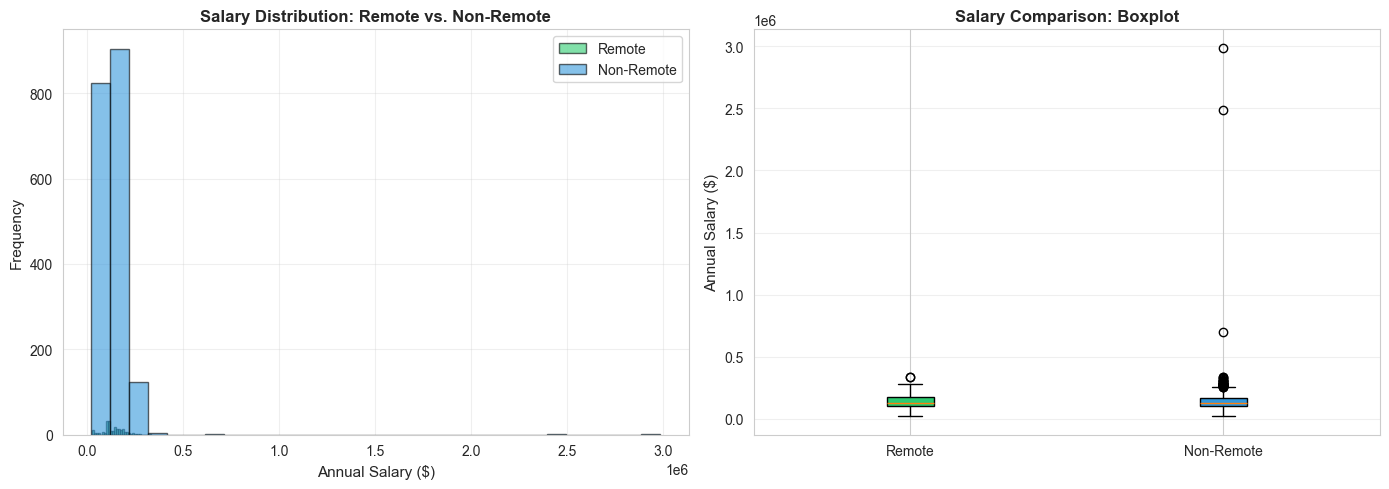


Visualization: Histogram and boxplot show salary distributions for both groups.


In [ ]:
# Visualization: Salary distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
axes[0].hist(salary_remote, bins=30, alpha=0.6, label='Remote', color='#2ecc71', edgecolor='black')
axes[0].hist(salary_non_remote, bins=30, alpha=0.6, label='Non-Remote', color='#3498db', edgecolor='black')
axes[0].set_xlabel('Annual Salary ($)', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Salary Distribution: Remote vs. Non-Remote', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Boxplots
salary_data = [salary_remote, salary_non_remote]
bp = axes[1].boxplot(salary_data, tick_labels=['Remote', 'Non-Remote'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#3498db')
axes[1].set_ylabel('Annual Salary ($)', fontsize=11)
axes[1].set_title('Salary Comparison: Boxplot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVisualization: Histogram and boxplot show salary distributions for both groups.")

In [ ]:
# Prepare data for sector analysis: Create a combined dataframe for contingency analysis
analysis_df = pd.concat([
    df_remote[['sector', 'source_dataset', 'salary_numeric', 'unique_skill_count']].assign(employment_type='Remote'),
    df_non_remote[['sector', 'source_dataset', 'salary_numeric', 'unique_skill_count']].assign(employment_type='Non-Remote')
], ignore_index=True)

# Remove rows with missing sector values for sector analysis
analysis_df_sector = analysis_df.dropna(subset=['sector'])

print("=" * 70)
print("SECTOR DISTRIBUTION: Remote vs. Non-Remote")
print("=" * 70)

# Contingency table
contingency_table = pd.crosstab(analysis_df_sector['sector'], analysis_df_sector['employment_type'])
print("\nContingency Table (counts):")
print(contingency_table)

# Add proportions
contingency_prop = pd.crosstab(analysis_df_sector['sector'], analysis_df_sector['employment_type'], normalize='index')
print("\nProportions by Sector (% Remote):")
sector_remote_pct = (contingency_table['Remote'] / (contingency_table['Remote'] + contingency_table['Non-Remote']) * 100).sort_values(ascending=False)
for sector, pct in sector_remote_pct.items():
    count_remote = contingency_table.loc[sector, 'Remote']
    count_total = contingency_table.loc[sector].sum()
    print(f"  {sector}: {pct:.1f}% ({count_remote}/{count_total})")

# Chi-square test
chi2, p_value_chi, dof, expected = stats.chi2_contingency(contingency_table)

print("\n" + "=" * 70)
print("CHI-SQUARE TEST (Independence of Sector and Remote Status)")
print("=" * 70)
print(f"H0: Sector and remote status are independent")
print(f"H1: Sector and remote status are associated")
print(f"\nChi-square statistic: {chi2:.4f}")
print(f"P-value: {p_value_chi:.6f}")
print(f"Degrees of freedom: {dof}")
print(f"Significance level (α): 0.05")

if p_value_chi < 0.05:
    print(f"\n✓ RESULT: Statistically SIGNIFICANT association (p = {p_value_chi:.6f} < 0.05)")
    print("  Remote work prevalence varies significantly by sector.")
else:
    print(f"\n✗ RESULT: NO statistically significant association (p = {p_value_chi:.6f} >= 0.05)")

SECTOR DISTRIBUTION: Remote vs. Non-Remote

Contingency Table (counts):
employment_type                              Non-Remote  Remote
sector                                                         
-1                                                  281      28
Aerospace & Defense                                  74       0
Construction, Repair & Maintenance Services           4       0
Education                                            38       3
Energy, Mining & Utilities                           10       1
Financial Services                                   76      22
Government & Public Administration                   26       2
Healthcare                                           66      44
Hotels & Travel Accommodation                         5       1
Human Resources & Staffing                            3       2
Information Technology                              329     102
Insurance                                            62       1
Legal                           

# Phase 3: Sector Distribution Analysis

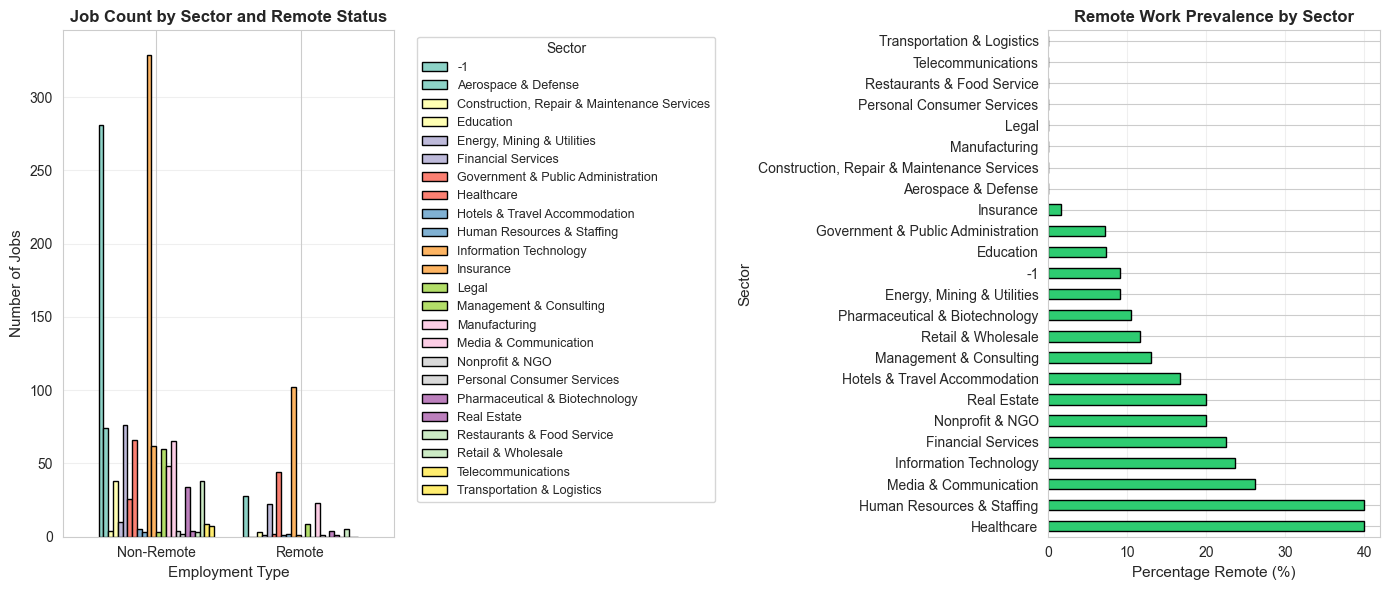


Visualization: Sector distribution across remote and non-remote positions.


In [ ]:
# Visualization: Sector distribution by remote status
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Stacked bar chart (counts)
contingency_table.T.plot(kind='bar', ax=axes[0], width=0.8, colormap='Set3', edgecolor='black')
axes[0].set_title('Job Count by Sector and Remote Status', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Employment Type', fontsize=11)
axes[0].set_ylabel('Number of Jobs', fontsize=11)
axes[0].legend(title='Sector', bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=9)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
axes[0].grid(True, alpha=0.3, axis='y')

# Bar chart of remote percentage by sector
sector_remote_pct.plot(kind='barh', ax=axes[1], color='#2ecc71', edgecolor='black')
axes[1].set_title('Remote Work Prevalence by Sector', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Percentage Remote (%)', fontsize=11)
axes[1].set_ylabel('Sector', fontsize=11)
axes[1].grid(True, alpha=0.3, axis='x')

plt.tight_layout()
plt.show()

print("\nVisualization: Sector distribution across remote and non-remote positions.")

In [ ]:
# Prepare skill count data (remove any zero counts)
skills_remote = df_remote['unique_skill_count'][df_remote['unique_skill_count'] > 0]
skills_non_remote = df_non_remote['unique_skill_count'][df_non_remote['unique_skill_count'] > 0]

print("=" * 70)
print("SKILL SPECIALIZATION (BREADTH): Remote vs. Non-Remote")
print("=" * 70)
print("Metric: Count of unique skills required per job posting")
print("(Higher count = broader skill set required; Lower count = more specialized)")

print("\nRemote Positions:")
print(f"  Count: {len(skills_remote)}")
print(f"  Mean unique skills: {skills_remote.mean():.2f}")
print(f"  Median unique skills: {skills_remote.median():.1f}")
print(f"  Std Dev: {skills_remote.std():.2f}")
print(f"  Min: {skills_remote.min():.0f}")
print(f"  Max: {skills_remote.max():.0f}")
print(f"  Q1 (25%): {skills_remote.quantile(0.25):.1f}")
print(f"  Q3 (75%): {skills_remote.quantile(0.75):.1f}")

print("\nNon-Remote Positions:")
print(f"  Count: {len(skills_non_remote)}")
print(f"  Mean unique skills: {skills_non_remote.mean():.2f}")
print(f"  Median unique skills: {skills_non_remote.median():.1f}")
print(f"  Std Dev: {skills_non_remote.std():.2f}")
print(f"  Min: {skills_non_remote.min():.0f}")
print(f"  Max: {skills_non_remote.max():.0f}")
print(f"  Q1 (25%): {skills_non_remote.quantile(0.25):.1f}")
print(f"  Q3 (75%): {skills_non_remote.quantile(0.75):.1f}")

print("\nDifference:")
mean_diff = skills_remote.mean() - skills_non_remote.mean()
if mean_diff > 0:
    print(f"  Remote jobs require {mean_diff:.2f} MORE unique skills on average (BROADER skill set)")
else:
    print(f"  Remote jobs require {abs(mean_diff):.2f} FEWER unique skills on average (MORE SPECIALIZED)")

# Mann-Whitney U Test
statistic_skills, p_value_skills = stats.mannwhitneyu(skills_remote, skills_non_remote, alternative='two-sided')

print("\n" + "=" * 70)
print("MANN-WHITNEY U TEST (Non-parametric)")
print("=" * 70)
print(f"H0: The skill breadth (unique skill count) distributions are equal")
print(f"H1: The skill breadth distributions differ")
print(f"\nU-statistic: {statistic_skills:.2f}")
print(f"P-value: {p_value_skills:.6f}")
print(f"Significance level (α): 0.05")

if p_value_skills < 0.05:
    print(f"\n✓ RESULT: Statistically SIGNIFICANT difference (p = {p_value_skills:.6f} < 0.05)")
    if mean_diff > 0:
        print("  Remote jobs significantly require BROADER skill sets (more unique skills)")
    else:
        print("  Remote jobs significantly require MORE SPECIALIZED sets (fewer unique skills)")
else:
    print(f"\n✗ RESULT: NO statistically significant difference (p = {p_value_skills:.6f} >= 0.05)")
    print("  Skill breadth requirements are similar across remote and non-remote positions.")

# Effect size
n1, n2 = len(skills_remote), len(skills_non_remote)
r_skills = 1 - (2 * statistic_skills) / (n1 * n2)
print(f"\nEffect size (rank biserial correlation): {r_skills:.4f}")

SKILL SPECIALIZATION (BREADTH): Remote vs. Non-Remote
Metric: Count of unique skills required per job posting
(Higher count = broader skill set required; Lower count = more specialized)

Remote Positions:
  Count: 367
  Mean unique skills: 14.68
  Median unique skills: 13.0
  Std Dev: 13.60
  Min: 1
  Max: 115
  Q1 (25%): 5.0
  Q3 (75%): 22.0

Non-Remote Positions:
  Count: 2077
  Mean unique skills: 14.42
  Median unique skills: 9.0
  Std Dev: 17.83
  Min: 1
  Max: 195
  Q1 (25%): 4.0
  Q3 (75%): 18.0

Difference:
  Remote jobs require 0.26 MORE unique skills on average (BROADER skill set)

MANN-WHITNEY U TEST (Non-parametric)
H0: The skill breadth (unique skill count) distributions are equal
H1: The skill breadth distributions differ

U-statistic: 415257.50
P-value: 0.006036
Significance level (α): 0.05

✓ RESULT: Statistically SIGNIFICANT difference (p = 0.006036 < 0.05)
  Remote jobs significantly require BROADER skill sets (more unique skills)

Effect size (rank biserial correlati

# Phase 4: Skill Specialization Analysis (Skill Breadth)

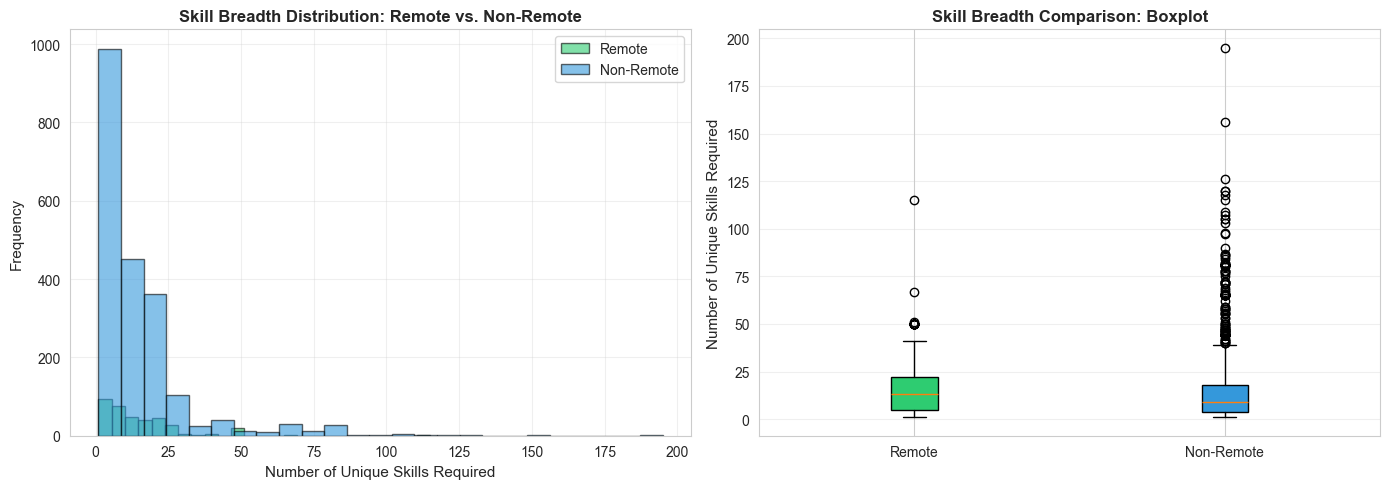


Visualization: Histogram and boxplot show skill breadth distributions for both groups.


In [ ]:
# Visualization: Skill count distributions
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Histograms
axes[0].hist(skills_remote, bins=25, alpha=0.6, label='Remote', color='#2ecc71', edgecolor='black')
axes[0].hist(skills_non_remote, bins=25, alpha=0.6, label='Non-Remote', color='#3498db', edgecolor='black')
axes[0].set_xlabel('Number of Unique Skills Required', fontsize=11)
axes[0].set_ylabel('Frequency', fontsize=11)
axes[0].set_title('Skill Breadth Distribution: Remote vs. Non-Remote', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)

# Boxplots
skill_data = [skills_remote, skills_non_remote]
bp = axes[1].boxplot(skill_data, tick_labels=['Remote', 'Non-Remote'], patch_artist=True)
bp['boxes'][0].set_facecolor('#2ecc71')
bp['boxes'][1].set_facecolor('#3498db')
axes[1].set_ylabel('Number of Unique Skills Required', fontsize=11)
axes[1].set_title('Skill Breadth Comparison: Boxplot', fontsize=12, fontweight='bold')
axes[1].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

print("\nVisualization: Histogram and boxplot show skill breadth distributions for both groups.")

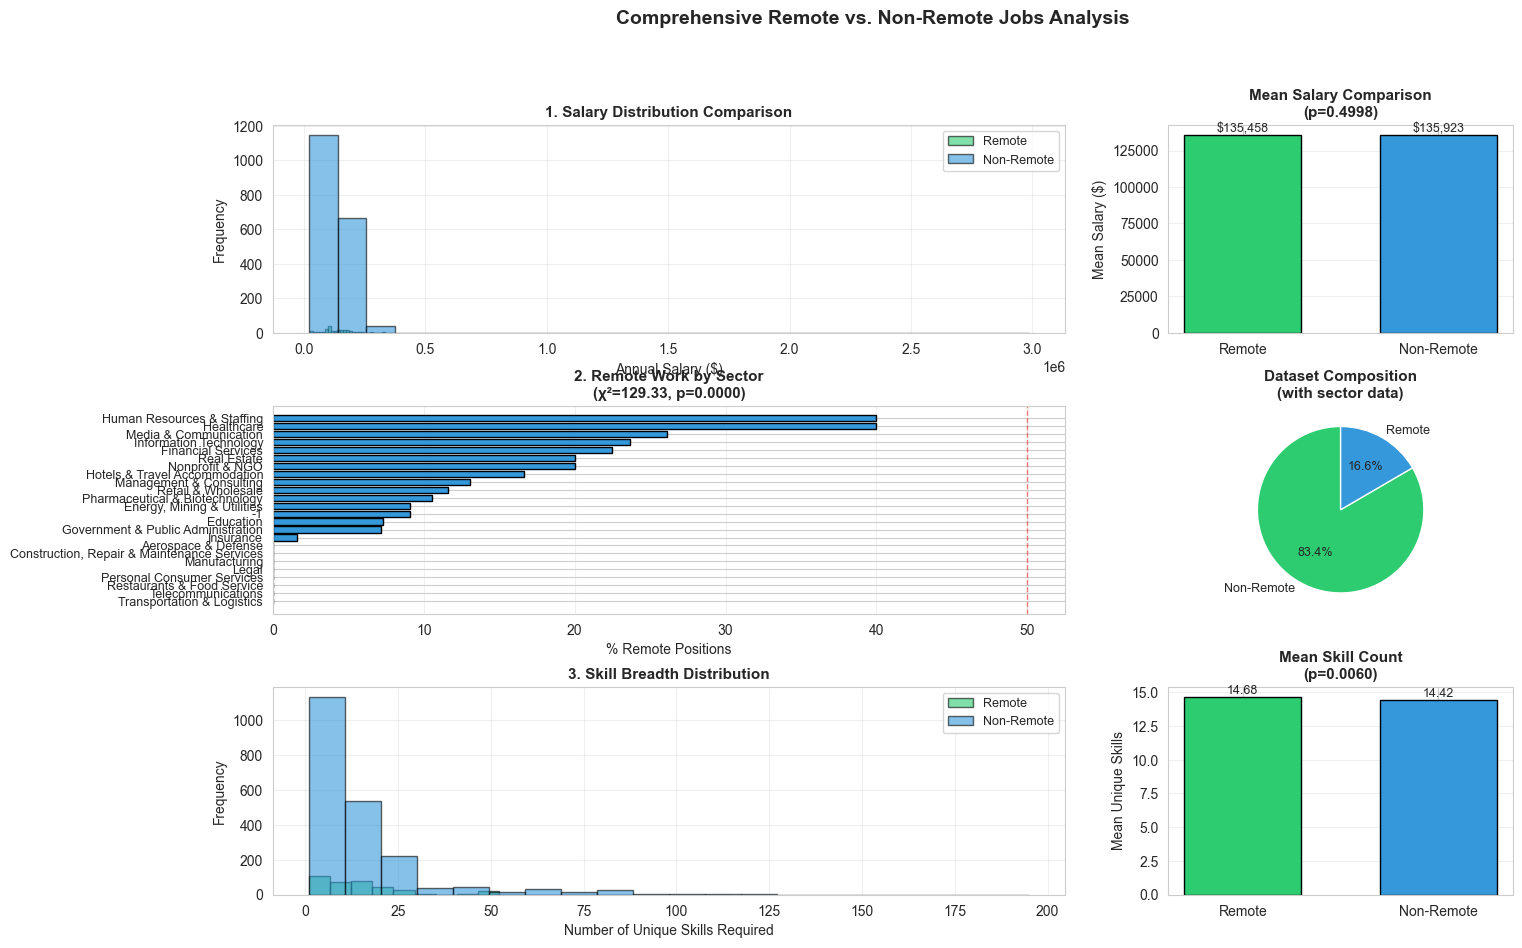


Dashboard: All three analyses visualized side-by-side for comprehensive comparison


In [ ]:
# Create comprehensive visualization dashboard
fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(3, 3, hspace=0.35, wspace=0.3)

# Row 1: SALARY ANALYSIS
ax1 = fig.add_subplot(gs[0, 0:2])
ax1.hist(salary_remote, bins=25, alpha=0.6, label='Remote', color='#2ecc71', edgecolor='black')
ax1.hist(salary_non_remote, bins=25, alpha=0.6, label='Non-Remote', color='#3498db', edgecolor='black')
ax1.set_xlabel('Annual Salary ($)', fontsize=10)
ax1.set_ylabel('Frequency', fontsize=10)
ax1.set_title('1. Salary Distribution Comparison', fontsize=11, fontweight='bold')
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)

ax2 = fig.add_subplot(gs[0, 2])
salary_means = [salary_remote.mean(), salary_non_remote.mean()]
salary_bars = ax2.bar(['Remote', 'Non-Remote'], salary_means, color=['#2ecc71', '#3498db'], edgecolor='black', width=0.6)
ax2.set_ylabel('Mean Salary ($)', fontsize=10)
ax2.set_title(f'Mean Salary Comparison\n(p={p_value:.4f})', fontsize=11, fontweight='bold')
ax2.grid(True, alpha=0.3, axis='y')
for bar, val in zip(salary_bars, salary_means):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width() / 2.0, height, f'${val:,.0f}', ha='center', va='bottom', fontsize=9)

# Row 2: SECTOR ANALYSIS
ax3 = fig.add_subplot(gs[1, 0:2])
sector_remote_pct_sorted = sector_remote_pct.sort_values(ascending=True)
colors = ['#2ecc71' if x > 50 else '#3498db' for x in sector_remote_pct_sorted.values]
ax3.barh(range(len(sector_remote_pct_sorted)), sector_remote_pct_sorted.values, color=colors, edgecolor='black')
ax3.set_yticks(range(len(sector_remote_pct_sorted)))
ax3.set_yticklabels(sector_remote_pct_sorted.index, fontsize=9)
ax3.set_xlabel('% Remote Positions', fontsize=10)
ax3.set_title(f'2. Remote Work by Sector\n(χ²={chi2:.2f}, p={p_value_chi:.4f})', fontsize=11, fontweight='bold')
ax3.grid(True, alpha=0.3, axis='x')
ax3.axvline(50, color='red', linestyle='--', linewidth=1, alpha=0.5, label='50% threshold')

ax4 = fig.add_subplot(gs[1, 2])
sector_counts = analysis_df_sector['employment_type'].value_counts()
ax4.pie(
    sector_counts.values,
    labels=sector_counts.index,
    autopct='%1.1f%%',
    colors=['#2ecc71', '#3498db'],
    startangle=90,
    textprops={'fontsize': 9},
)
ax4.set_title('Dataset Composition\n(with sector data)', fontsize=11, fontweight='bold')

# Row 3: SKILL BREADTH ANALYSIS
ax5 = fig.add_subplot(gs[2, 0:2])
ax5.hist(skills_remote, bins=20, alpha=0.6, label='Remote', color='#2ecc71', edgecolor='black')
ax5.hist(skills_non_remote, bins=20, alpha=0.6, label='Non-Remote', color='#3498db', edgecolor='black')
ax5.set_xlabel('Number of Unique Skills Required', fontsize=10)
ax5.set_ylabel('Frequency', fontsize=10)
ax5.set_title('3. Skill Breadth Distribution', fontsize=11, fontweight='bold')
ax5.legend(fontsize=9)
ax5.grid(True, alpha=0.3)

ax6 = fig.add_subplot(gs[2, 2])
skill_means = [skills_remote.mean(), skills_non_remote.mean()]
skill_bars = ax6.bar(['Remote', 'Non-Remote'], skill_means, color=['#2ecc71', '#3498db'], edgecolor='black', width=0.6)
ax6.set_ylabel('Mean Unique Skills', fontsize=10)
ax6.set_title(f'Mean Skill Count\n(p={p_value_skills:.4f})', fontsize=11, fontweight='bold')
ax6.grid(True, alpha=0.3, axis='y')
for bar, val in zip(skill_bars, skill_means):
    height = bar.get_height()
    ax6.text(bar.get_x() + bar.get_width() / 2.0, height, f'{val:.2f}', ha='center', va='bottom', fontsize=9)

plt.suptitle('Comprehensive Remote vs. Non-Remote Jobs Analysis', fontsize=14, fontweight='bold', y=0.995)
plt.show()

print("\n" + "=" * 80)
print("Dashboard: All three analyses visualized side-by-side for comprehensive comparison")
print("=" * 80)

In [ ]:
# Create comprehensive summary table
summary_data = {
    'Metric': [
        'Salary - Mean (USD)',
        'Salary - Median (USD)',
        'Salary - Std Dev (USD)',
        'Salary - Count',
        'Skill Count - Mean',
        'Skill Count - Median',
        'Skill Count - Std Dev',
        'Skill Count - Count',
        'Total Job Postings'
    ],
    'Remote': [
        f"${salary_remote.mean():,.0f}",
        f"${salary_remote.median():,.0f}",
        f"${salary_remote.std():,.0f}",
        len(salary_remote),
        f"{skills_remote.mean():.2f}",
        f"{skills_remote.median():.1f}",
        f"{skills_remote.std():.2f}",
        len(skills_remote),
        len(df_remote)
    ],
    'Non-Remote': [
        f"${salary_non_remote.mean():,.0f}",
        f"${salary_non_remote.median():,.0f}",
        f"${salary_non_remote.std():,.0f}",
        len(salary_non_remote),
        f"{skills_non_remote.mean():.2f}",
        f"{skills_non_remote.median():.1f}",
        f"{skills_non_remote.std():.2f}",
        len(skills_non_remote),
        len(df_non_remote)
    ]
}

summary_df = pd.DataFrame(summary_data)

print("\n" + "=" * 80)
print("COMPREHENSIVE SUMMARY TABLE")
print("=" * 80)
print(summary_df.to_string(index=False))

# Statistical tests summary
print("\n" + "=" * 80)
print("STATISTICAL TEST RESULTS SUMMARY")
print("=" * 80)

test_results = {
    'Analysis': [
        'Salary Levels',
        'Sector Distribution',
        'Skill Breadth'
    ],
    'Test Used': [
        'Mann-Whitney U',
        'Chi-Square',
        'Mann-Whitney U'
    ],
    'Test Statistic': [
        f"{statistic:.2f}",
        f"{chi2:.4f}",
        f"{statistic_skills:.2f}"
    ],
    'P-value': [
        f"{p_value:.6f}",
        f"{p_value_chi:.6f}",
        f"{p_value_skills:.6f}"
    ],
    'Significant (α=0.05)': [
        '✓ YES' if p_value < 0.05 else '✗ NO',
        '✓ YES' if p_value_chi < 0.05 else '✗ NO',
        '✓ YES' if p_value_skills < 0.05 else '✗ NO'
    ],
    'Effect Size': [
        f"{r:.4f}",
        "-",
        f"{r_skills:.4f}"
    ]
}

tests_df = pd.DataFrame(test_results)
print(tests_df.to_string(index=False))

# Key findings
print("\n" + "=" * 80)
print("KEY FINDINGS")
print("=" * 80)

print("\n1. SALARY LEVELS:")
salary_finding = f"   Remote positions have a mean salary of ${salary_remote.mean():,.0f} vs. ${salary_non_remote.mean():,.0f} for non-remote."
salary_diff = salary_remote.mean() - salary_non_remote.mean()
if abs(salary_diff) > 5000:
    salary_finding += f"\n   Difference: ${abs(salary_diff):,.0f} ({'HIGHER' if salary_diff > 0 else 'LOWER'} for remote)"
if p_value < 0.05:
    salary_finding += f"\n   ✓ This difference is STATISTICALLY SIGNIFICANT (p={p_value:.6f})"
else:
    salary_finding += f"\n   ✗ No statistically significant difference in salary levels (p={p_value:.6f})"
print(salary_finding)

print("\n2. SECTOR DISTRIBUTION:")
print(f"   Chi-square test: χ² = {chi2:.4f}, p = {p_value_chi:.6f}")
if p_value_chi < 0.05:
    print(f"   ✓ Remote work prevalence VARIES SIGNIFICANTLY by sector")
    print(f"   Top sectors for remote work:")
    for sector, pct in sector_remote_pct.head(3).items():
        print(f"      - {sector}: {pct:.1f}% remote")
else:
    print(f"   ✗ No significant association between sector and remote work")

print("\n3. SKILL SPECIALIZATION (BREADTH):")
skill_finding = f"   Remote positions require {skills_remote.mean():.2f} unique skills on average vs. {skills_non_remote.mean():.2f} for non-remote."
skill_diff = skills_remote.mean() - skills_non_remote.mean()
if abs(skill_diff) > 0.5:
    if skill_diff > 0:
        skill_finding += f"\n   Remote jobs require {skill_diff:.2f} MORE unique skills (BROADER skill set)"
    else:
        skill_finding += f"\n   Remote jobs require {abs(skill_diff):.2f} FEWER unique skills (MORE SPECIALIZED)"
if p_value_skills < 0.05:
    skill_finding += f"\n   ✓ This difference is STATISTICALLY SIGNIFICANT (p={p_value_skills:.6f})"
else:
    skill_finding += f"\n   ✗ No statistically significant difference in skill breadth (p={p_value_skills:.6f})"
print(skill_finding)

print("\n" + "=" * 80)
print("HYPOTHESIS TEST")
print("=" * 80)
print("\nOriginal Hypothesis from README.md:")
print("'Remote positions will more frequently require specialized and self-directed")
print(" skills compared to non-remote roles, which will emphasize broader skill sets.'")
print("\nHypothesis Interpretation:")
print("- Remote = FEWER unique skills (more specialized)")
print("- Non-remote = MORE unique skills (broader)")
print("\nNull Hypothesis (H₀): Skill breadth is equal between remote and non-remote")
print("Alternative Hypothesis (H₁): Remote jobs have different skill breadth")

if p_value_skills < 0.05:
    print(f"\nResult: STATISTICALLY SIGNIFICANT difference detected (p = {p_value_skills:.6f})")
    if skills_remote.mean() < skills_non_remote.mean():
        print("✓ HYPOTHESIS SUPPORTED: Remote jobs require FEWER unique skills (more specialized)")
        print(f"  Remote: {skills_remote.mean():.2f} unique skills | Non-remote: {skills_non_remote.mean():.2f} unique skills")
    else:
        print("✗ HYPOTHESIS CONTRADICTED: Remote jobs require MORE unique skills (broader)")
        print(f"  Remote: {skills_remote.mean():.2f} unique skills | Non-remote: {skills_non_remote.mean():.2f} unique skills")
else:
    print(f"\nResult: NO statistically significant difference (p = {p_value_skills:.6f})")
    print("✗ CANNOT SUPPORT HYPOTHESIS: Skill breadth requirements are similar across remote/non-remote")


COMPREHENSIVE SUMMARY TABLE
                Metric   Remote Non-Remote
   Salary - Mean (USD) $135,458   $135,923
 Salary - Median (USD) $127,750   $125,440
Salary - Std Dev (USD)  $56,015   $101,106
        Salary - Count      210       1859
    Skill Count - Mean    14.68      14.42
  Skill Count - Median     13.0        9.0
 Skill Count - Std Dev    13.60      17.83
   Skill Count - Count      367       2077
    Total Job Postings      367       2077

STATISTICAL TEST RESULTS SUMMARY
           Analysis      Test Used Test Statistic  P-value Significant (α=0.05) Effect Size
      Salary Levels Mann-Whitney U      200732.50 0.499838                 ✗ NO     -0.0284
Sector Distribution     Chi-Square       129.3284 0.000000                ✓ YES           -
      Skill Breadth Mann-Whitney U      415257.50 0.006036                ✓ YES     -0.0895

KEY FINDINGS

1. SALARY LEVELS:
   Remote positions have a mean salary of $135,458 vs. $135,923 for non-remote.
   ✗ No statistically sign